In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [98]:
df = pd.read_csv("BBC_news_dataset.csv")
df.head()

,Unnamed: 0,description,tags
0,0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2410 non-null   int64 
 1   description  2410 non-null   object
 2   tags         2392 non-null   object
dtypes: int64(1), object(2)
memory usage: 56.6+ KB


In [100]:
df.isnull().sum()

Unnamed: 0      0
description     0
tags           18
dtype: int64

In [101]:
print("Shape", df.shape)

Shape (2410, 3)


In [102]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Unnamed: 0', 'description', 'tags'], dtype='object')


In [103]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [104]:
df.head()

,description,tags
0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


In [105]:
df.describe(include="all")

,description,tags
count,2410,2392
unique,2128,2149
top,tmobile bets on pocket office tmobile has lau...,"technology, business, london, skype, virgin me..."
freq,4,4


In [106]:
df.duplicated().sum()

np.int64(219)

In [107]:
df["article_length"] = df["description"].apply(len)

In [108]:
df.head()

,description,tags,article_length
0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,...",2578
1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ...",3594
2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,...",1256
3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'...",2285
4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta...",1018


In [109]:
df["article_length"].describe()

count     2410.000000
mean      2223.687967
std       1271.382818
min         57.000000
25%       1421.250000
50%       1941.500000
75%       2762.000000
max      15672.000000
Name: article_length, dtype: float64

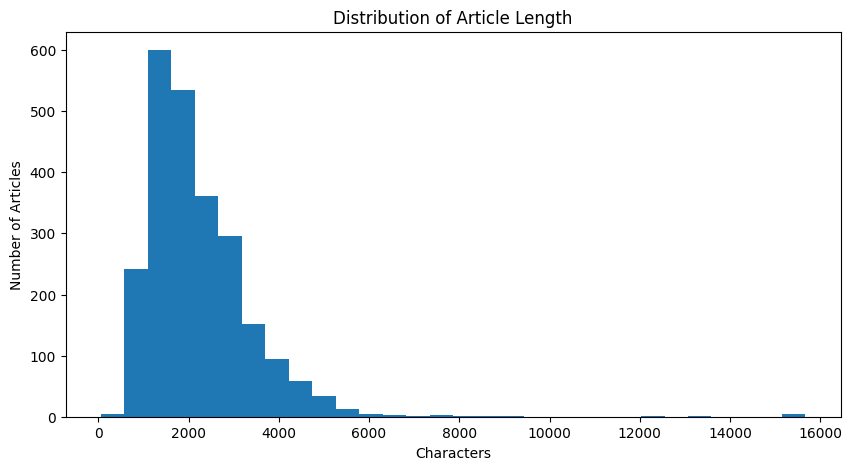

In [110]:
plt.figure(figsize=(10,5))

plt.hist(df["article_length"], bins=30)

plt.title("Distribution of Article Length")

plt.xlabel("Characters")

plt.ylabel("Number of Articles")

plt.show()

In [111]:
print(df["description"][0])

chelsea sack mutu  chelsea have sacked adrian mutu after he failed a drugs test  the yearold tested positive for a banned substance  which he later denied was cocaine  in october chelsea have decided to write off a possible transfer fee for mutu a m signing from parma last season who may face a twoyear suspension a statement from chelsea explaining the decision readwe want to make clear that chelsea has a zero tolerance policy towards drugs mutu scored six goals in his first five games after arriving at stamford bridge but his form went into decline and he was frozen out by coach jose mourinho chelseas statement added this applies to both performanceenhancing drugs or socalled recreational drugs they have no place at our club or in sport in coming to a decision on this case chelsea believed the clubs social responsibility to its fans players employees and other stakeholders in football regarding drugs was more important than the major financial considerations to the company any player 

In [112]:
print(df["tags"][0])

sports, stamford bridge, football association, fifa, michelle verroken, adrian mutu, jose mourinho, player, coach, director of drug-free sport for uk sport, spokesman, association football, adrian mutu, chelsea f.c., josé mourinho, doping in sport, transfer, english footballers, doping in association football, football, the football association


In [113]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [114]:
df["tags"] = df["tags"].fillna("")

In [115]:
df["clean_text"] = df["description"]

In [116]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x)
)

In [117]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

In [118]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [119]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [120]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

In [121]:
stop_words = set(stopwords.words("english"))

In [122]:
df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [123]:
lemmatizer = WordNetLemmatizer()

In [124]:
df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [125]:
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [126]:
print("Original Article:\n")
print(df.loc[0, "description"])

print("\n" + "="*80 + "\n")

print("Processed Article:\n")
print(df.loc[0, "processed_text"])

Original Article:

chelsea sack mutu  chelsea have sacked adrian mutu after he failed a drugs test  the yearold tested positive for a banned substance  which he later denied was cocaine  in october chelsea have decided to write off a possible transfer fee for mutu a m signing from parma last season who may face a twoyear suspension a statement from chelsea explaining the decision readwe want to make clear that chelsea has a zero tolerance policy towards drugs mutu scored six goals in his first five games after arriving at stamford bridge but his form went into decline and he was frozen out by coach jose mourinho chelseas statement added this applies to both performanceenhancing drugs or socalled recreational drugs they have no place at our club or in sport in coming to a decision on this case chelsea believed the clubs social responsibility to its fans players employees and other stakeholders in football regarding drugs was more important than the major financial considerations to the 

In [127]:
df.to_csv("BBC_news_processed.csv", index=False)

In [128]:
df = pd.read_csv("BBC_news_processed.csv")
df.head()

,description,tags,article_length,clean_text,tokens,processed_text
0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,...",2578,chelsea sack mutu chelsea have sacked adrian m...,"['chelsea', 'sack', 'mutu', 'chelsea', 'sacked...",chelsea sack mutu chelsea sacked adrian mutu f...
1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ...",3594,record fails to lift lacklustre meet yelena is...,"['record', 'fails', 'lift', 'lacklustre', 'mee...",record fails lift lacklustre meet yelena isinb...
2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,...",1256,edu describes tunnel fracas arsenals edu has l...,"['edu', 'describes', 'tunnel', 'fracas', 'arse...",edu describes tunnel fracas arsenal edu lifted...
3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'...",2285,ogara revels in ireland victory ireland flyhal...,"['ogara', 'revel', 'ireland', 'victory', 'irel...",ogara revel ireland victory ireland flyhalf ro...
4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta...",1018,unclear future for striker baros liverpool for...,"['unclear', 'future', 'striker', 'baros', 'liv...",unclear future striker baros liverpool forward...
